In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [159]:
df = pd.read_csv("online_retail.csv")

In [160]:
df.shape

(5711, 8)

In [161]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [162]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5706,536874,22961,JAM MAKING SET PRINTED,1,12/3/2010 11:35,1.45,16891.0,United Kingdom
5707,536874,22144,CHRISTMAS CRAFT LITTLE FRIENDS,1,12/3/2010 11:35,2.10,16891.0,United Kingdom
5708,536874,82483,WOOD 2 DRAWER CABINET WHITE FINISH,2,12/3/2010 11:35,5.95,16891.0,United Kingdom
5709,536874,22702,BLACK AND WHITE CAT BOWL,1,12/3/2010 11:35,2.10,16891.0,United Kingdom
5710,536874,21462,"NURSERY A,B,C PAINTED LETTERS",1,12/3/2010 11:35,6.75,16891.0,United Kingdom


In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5711 entries, 0 to 5710
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5711 non-null   str    
 1   StockCode    5711 non-null   str    
 2   Description  5699 non-null   str    
 3   Quantity     5711 non-null   int64  
 4   InvoiceDate  5711 non-null   str    
 5   UnitPrice    5711 non-null   float64
 6   CustomerID   4237 non-null   float64
 7   Country      5711 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 357.1 KB


In [164]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,5711.000000,5711.000000,4237.000000
mean,8.788128,4.077270,15855.829832
std,135.750251,14.582375,1758.250202
min,-9360.000000,0.000000,12427.000000
25%,1.000000,1.250000,14573.000000
50%,3.000000,2.510000,15862.000000
75%,10.000000,4.250000,17841.000000
max,2880.000000,607.490000,18239.000000


In [165]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [166]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [167]:
df["StockCode"].nunique()


1670

In [168]:
df["Country"].unique()


<StringArray>
['United Kingdom',         'France',      'Australia',    'Netherlands',
        'Germany',         'Norway',           'EIRE',    'Switzerland']
Length: 8, dtype: str

In [169]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      12
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1474
Country           0
dtype: int64

In [170]:
df[df["CustomerID"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
5682,536865,85152,HAND OVER THE CHOCOLATE SIGN,1,12/3/2010 11:28,4.21,NaN,United Kingdom
5683,536865,85176,SEWING SUSAN 21 NEEDLE SET,1,12/3/2010 11:28,1.66,NaN,United Kingdom
5684,536865,M,Manual,1,12/3/2010 11:28,2.55,NaN,United Kingdom
5685,536865,DOT,DOTCOM POSTAGE,1,12/3/2010 11:28,498.47,NaN,United Kingdom


In [171]:
df.duplicated().sum()

np.int64(92)

In [172]:
df = df.drop_duplicates()

In [173]:
df.shape

(5619, 8)

In [174]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [175]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [176]:
df.dtypes


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [177]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
5259,C536853,84678,CLASSICAL ROSE SMALL VASE,-1,2010-12-03 10:07:00,2.55,14679.0,United Kingdom
5260,C536854,22158,3 HEARTS HANGING DECORATION RUSTIC,-1,2010-12-03 10:09:00,2.95,15240.0,United Kingdom
5261,C536854,22944,CHRISTMAS METAL POSTCARD WITH BELLS,-1,2010-12-03 10:09:00,1.25,15240.0,United Kingdom
5262,C536854,21871,SAVE THE PLANET MUG,-1,2010-12-03 10:09:00,1.25,15240.0,United Kingdom


In [178]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [179]:
df[df["Quantity"] < 0].shape

(82, 8)

In [180]:
df = df[df["Quantity"] >= 0]

In [181]:
df.shape

(5537, 8)

In [182]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      10
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1472
Country           0
dtype: int64

In [183]:
df["Description"] = df["Description"].fillna("Unknown")

In [184]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1472
Country           0
dtype: int64

In [185]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [186]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [187]:
df["CustomerID"] = df["CustomerID"].astype("Int64")

In [188]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
dtype: object

In [189]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [190]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayName"] = df["InvoiceDate"].dt.day_name()


In [191]:
df["IsReturn"] = df["Quantity"] < 0


In [192]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'DayName', 'IsReturn'],
      dtype='str')

In [193]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayName,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False


In [194]:
# Total Revenue
df["Revenue"].sum()

np.float64(115615.8)

In [195]:
# Average order value
order_revenue = df.groupby("InvoiceNo")["Revenue"].sum()
aov = order_revenue.mean()

In [196]:
aov

np.float64(390.5939189189189)

In [197]:
order_revenue

InvoiceNo
536365     139.12
536366      22.20
536367     278.73
536368      70.05
536369      17.85
           ...   
536863     112.27
536864     636.68
536865    2396.96
536866       8.47
536874      78.01
Name: Revenue, Length: 296, dtype: float64

In [198]:
# Number of Invoice No.
df["InvoiceNo"].count()

np.int64(5537)

In [199]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1472
Country           0
Revenue           0
Year              0
Month             0
Day               0
Hour              0
DayName           0
IsReturn          0
dtype: int64

In [200]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
Revenue               float64
Year                    int32
Month                   int32
Day                     int32
Hour                    int32
DayName                   str
IsReturn                 bool
dtype: object

In [201]:
df["UnitPrice"] = df["UnitPrice"].astype(int)

In [202]:
sales_df = df[df["IsReturn"] == False]


In [203]:
sales_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayName,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2,17850,United Kingdom,15.30,2010,12,1,8,Wednesday,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2,17850,United Kingdom,22.00,2010,12,1,8,Wednesday,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5706,536874,22961,JAM MAKING SET PRINTED,1,2010-12-03 11:35:00,1,16891,United Kingdom,1.45,2010,12,3,11,Friday,False
5707,536874,22144,CHRISTMAS CRAFT LITTLE FRIENDS,1,2010-12-03 11:35:00,2,16891,United Kingdom,2.10,2010,12,3,11,Friday,False
5708,536874,82483,WOOD 2 DRAWER CABINET WHITE FINISH,2,2010-12-03 11:35:00,5,16891,United Kingdom,11.90,2010,12,3,11,Friday,False
5709,536874,22702,BLACK AND WHITE CAT BOWL,1,2010-12-03 11:35:00,2,16891,United Kingdom,2.10,2010,12,3,11,Friday,False


In [204]:
sales_df.shape

(5537, 15)

In [205]:
# unique invoices
df["InvoiceNo"].nunique()


296

In [206]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'DayName', 'IsReturn'],
      dtype='str')

In [207]:
# unique products sold
df["StockCode"].nunique()

1660

In [208]:
# unique customers
df['CustomerID'].nunique()

200

In [209]:
# total units sold
sales_df["Quantity"].sum()

np.int64(60785)

In [210]:
# Average quantity per order
df.groupby("InvoiceNo")["Quantity"].mean()

InvoiceNo
536365    5.714286
536366    6.000000
536367    6.916667
536368    3.750000
536369    3.000000
            ...   
536863    1.738095
536864    1.404255
536865    2.264286
536866    1.000000
536874    1.478261
Name: Quantity, Length: 296, dtype: float64

In [211]:
# Average unitprice
df["UnitPrice"].mean()

np.float64(3.5295286256095357)

In [212]:
# Largest order by revenue
df["Revenue"].max()

np.float64(1627.2)

In [213]:
# 10 products have highest quantity sold
top_10_products = (
    sales_df.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_products)

StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     3312
84950      ASSORTED COLOUR T-LIGHT HOLDER        1842
21915      RED  HARMONICA IN BOX                 1549
85123A     WHITE HANGING HEART T-LIGHT HOLDER     769
84879      ASSORTED COLOUR BIRD ORNAMENT          727
21212      PACK OF 72 RETROSPOT CAKE CASES        700
84029E     RED WOOLLY HOTTIE WHITE HEART.         686
22616      PACK OF 12 LONDON TISSUES              656
21232      STRAWBERRY CERAMIC TRINKET BOX         617
21137      BLACK RECORD COVER FRAME               613
Name: Quantity, dtype: int64


In [214]:
# Top 10 products generate highest revenue
top_10_products_revenue= (
    sales_df.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products_revenue

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              3671.28
84029E     RED WOOLLY HOTTIE WHITE HEART.        2132.88
21137      BLACK RECORD COVER FRAME              2078.43
DOT        DOTCOM POSTAGE                        2051.22
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2045.43
22752      SET 7 BABUSHKA NESTING BOXES          1870.00
21915      RED  HARMONICA IN BOX                 1676.55
79321      CHILLI LIGHTS                         1368.00
22086      PAPER CHAIN KIT 50'S CHRISTMAS        1282.20
84879      ASSORTED COLOUR BIRD ORNAMENT         1163.83
Name: Revenue, dtype: float64

In [215]:
# products appear in the most orders
top_products_orders = (
    sales_df.groupby(["StockCode", "Description"])["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_products_orders

StockCode  Description                        
85123A     WHITE HANGING HEART T-LIGHT HOLDER     39
22633      HAND WARMER UNION JACK                 34
84029E     RED WOOLLY HOTTIE WHITE HEART.         30
22961      JAM MAKING SET PRINTED                 29
84029G     KNITTED UNION FLAG HOT WATER BOTTLE    27
22752      SET 7 BABUSHKA NESTING BOXES           26
22866      HAND WARMER SCOTTY DOG DESIGN          24
22865      HAND WARMER OWL DESIGN                 24
37370      RETRO COFFEE MUGS ASSORTED             24
22086      PAPER CHAIN KIT 50'S CHRISTMAS         23
Name: InvoiceNo, dtype: int64

In [216]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'DayName', 'IsReturn'],
      dtype='str')

In [217]:
# products have the highest average selling price
highest_average_selling_price = (
    sales_df.groupby(["StockCode", "Description"])["UnitPrice"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

highest_average_selling_price

StockCode  Description                       
DOT        DOTCOM POSTAGE                        409.8
22655      VINTAGE RED KITCHEN CABINET           295.0
22827      RUSTIC  SEVENTEEN DRAWER SIDEBOARD    165.0
21769      VINTAGE POST OFFICE CABINET            79.0
22769      CHALKBOARD KITCHEN ORGANISER           51.0
C2         CARRIAGE                               50.0
22503      CABIN BAG VINTAGE PAISLEY              44.0
22803      IVORY EMBROIDERED QUILT                35.0
22947      WOODEN ADVENT CALENDAR RED             29.5
21761      WOOD AND GLASS MEDICINE CABINET        29.0
Name: UnitPrice, dtype: float64

In [218]:
highest_revenue_products = (
    sales_df.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

highest_revenue_products

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              3671.28
84029E     RED WOOLLY HOTTIE WHITE HEART.        2132.88
21137      BLACK RECORD COVER FRAME              2078.43
DOT        DOTCOM POSTAGE                        2051.22
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2045.43
22752      SET 7 BABUSHKA NESTING BOXES          1870.00
21915      RED  HARMONICA IN BOX                 1676.55
79321      CHILLI LIGHTS                         1368.00
22086      PAPER CHAIN KIT 50'S CHRISTMAS        1282.20
84879      ASSORTED COLOUR BIRD ORNAMENT         1163.83
Name: Revenue, dtype: float64

In [219]:
comparison = pd.concat(
    [top_products_orders, highest_revenue_products],
    axis=1,
    keys=["OrderCount", "Revenue"]
)

print(comparison)

                                               OrderCount  Revenue
StockCode Description                                             
85123A    WHITE HANGING HEART T-LIGHT HOLDER         39.0  2045.43
22633     HAND WARMER UNION JACK                     34.0      NaN
84029E    RED WOOLLY HOTTIE WHITE HEART.             30.0  2132.88
22961     JAM MAKING SET PRINTED                     29.0      NaN
84029G    KNITTED UNION FLAG HOT WATER BOTTLE        27.0      NaN
22752     SET 7 BABUSHKA NESTING BOXES               26.0  1870.00
22866     HAND WARMER SCOTTY DOG DESIGN              24.0      NaN
22865     HAND WARMER OWL DESIGN                     24.0      NaN
37370     RETRO COFFEE MUGS ASSORTED                 24.0      NaN
22086     PAPER CHAIN KIT 50'S CHRISTMAS             23.0  1282.20
22423     REGENCY CAKESTAND 3 TIER                    NaN  3671.28
21137     BLACK RECORD COVER FRAME                    NaN  2078.43
DOT       DOTCOM POSTAGE                              NaN  205

In [220]:
# No, the most frequently ordered products are not necessarily the highest-revenue products.

In [221]:
product_analysis = (
    sales_df.groupby(["StockCode", "Description"])
    .agg(
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum")
    )
)

print(product_analysis)

                                          TotalQuantity  TotalRevenue
StockCode    Description                                             
10002        INFLATABLE POLITICAL GLOBE              67         61.00
10120        DOGGY RUBBER                             1          0.21
10123C       HEARTS WRAPPING TAPE                     1          0.65
10124G       ARMY CAMO BOOKCOVER TAPE                 5          2.10
10125        MINI FUNKY DESIGN TAPES                  2          1.70
...                                                 ...           ...
BANK CHARGES Bank Charges                             1         15.00
C2           CARRIAGE                                 1         50.00
DOT          DOTCOM POSTAGE                           5       2051.22
M            Manual                                   3         22.75
POST         POSTAGE                                 12        257.00

[1668 rows x 2 columns]


In [222]:
high_quantity_low_revenue = product_analysis[
    (product_analysis["TotalQuantity"] > product_analysis["TotalQuantity"].median()) &
    (product_analysis["TotalRevenue"] < product_analysis["TotalRevenue"].median())
]

print(high_quantity_low_revenue.sort_values("TotalQuantity", ascending=False))

                                               TotalQuantity  TotalRevenue
StockCode Description                                                     
17003     BROCADE RING PURSE                              75         16.41
22139     Unknown                                         56          0.00
21984     PACK OF 12 PINK PAISLEY TISSUES                 50         15.06
22614     PACK OF 12 SPACEBOY TISSUES                     49         14.77
16235     RECYCLED PENCIL WITH RABBIT ERASER              48         10.08
...                                                      ...           ...
20981     12 PENCILS TALL TUBE WOODLAND                    9          8.46
21244     BLUE POLKADOT PLATE                              9         15.21
21823     PAINTED METAL HEART WITH HOLLY BELL              9         16.11
22753     SMALL YELLOW BABUSHKA NOTEBOOK                   9          7.65
85049H    URBAN BLACK RIBBONS                              9         12.51

[161 rows x 2 columns]


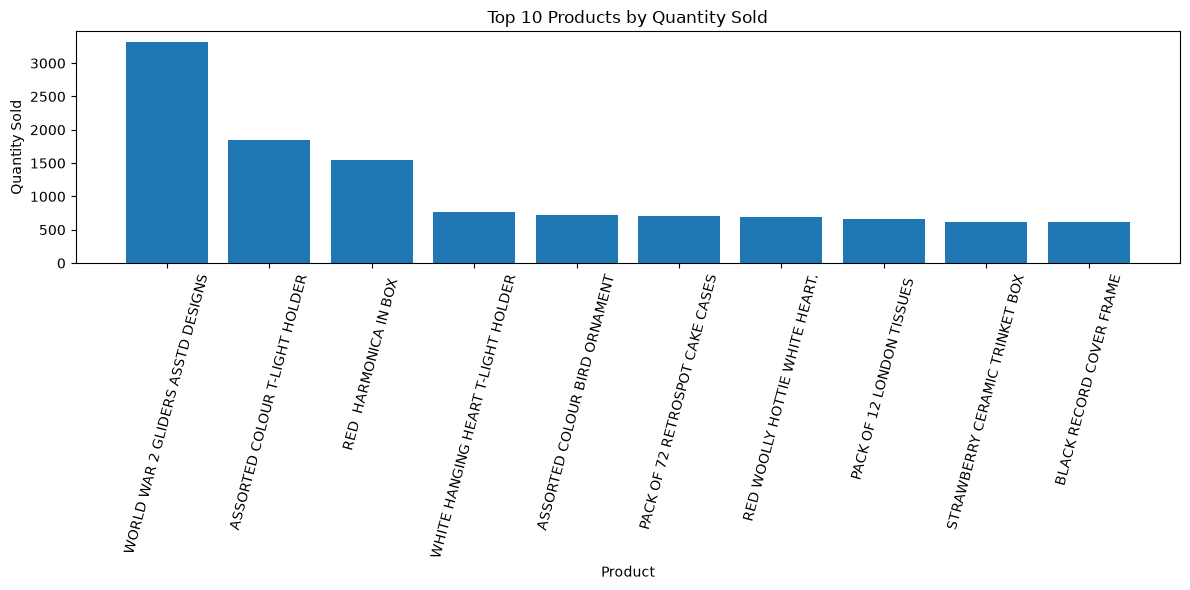

In [ ]:
# top products by quantity

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_products.index.get_level_values("Description"),
    top_10_products.values
)

plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.title("Top 10 Products by Quantity Sold")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

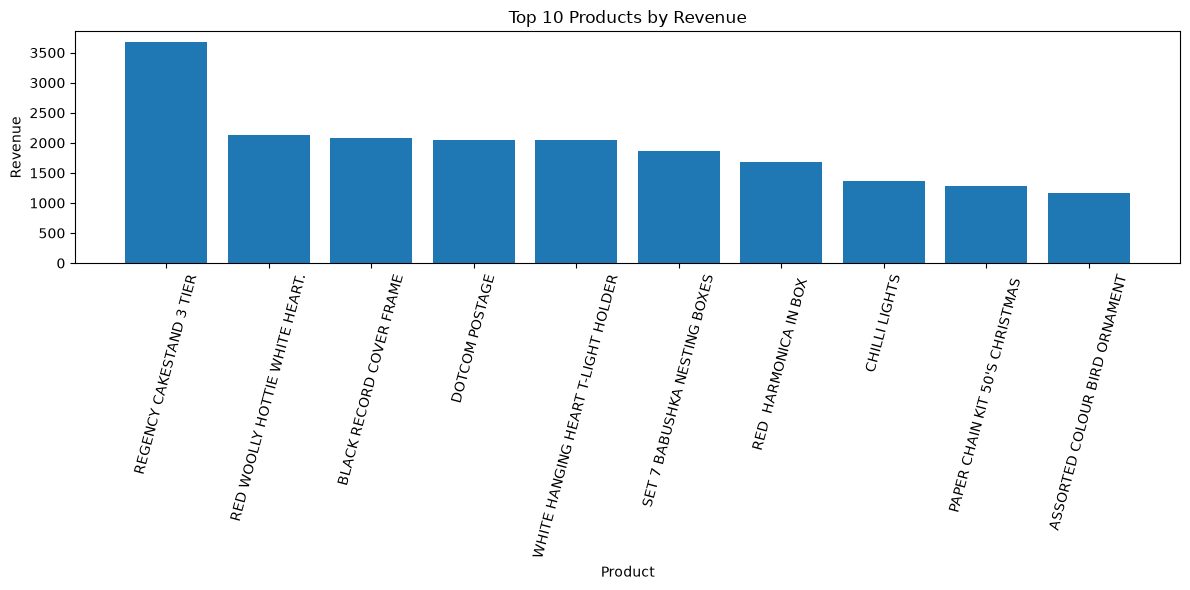

In [ ]:
# top products by revenue

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_products_revenue.index.get_level_values("Description"),
    top_10_products_revenue.values
)

plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Top 10 Products by Revenue")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [230]:
# countries in dataset
df["Country"].nunique()

8

In [232]:
sales_df["Country"] = sales_df["Country"].replace({"EIRE": "Ireland"})

In [234]:
sales_df["Country"].unique()

<StringArray>
['United Kingdom',         'France',      'Australia',    'Netherlands',
        'Germany',         'Norway',        'Ireland',    'Switzerland']
Length: 8, dtype: str

In [235]:
country_highest_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_highest_revenue


Country
United Kingdom    110599.20
Norway              1919.14
France               945.00
Germany              720.33
Ireland              577.88
Australia            358.25
Switzerland          303.40
Netherlands          192.60
Name: Revenue, dtype: float64

In [236]:
sales_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'DayName', 'IsReturn'],
      dtype='str')

In [237]:
most_orders = (
    sales_df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

most_orders

Country
United Kingdom    284
Ireland             3
Germany             3
France              2
Australia           1
Netherlands         1
Norway              1
Switzerland         1
Name: InvoiceNo, dtype: int64

In [238]:
top_countries_customers = (
    sales_df.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(top_countries_customers)

Country
United Kingdom    190
Germany             3
France              2
Australia           1
Ireland             1
Netherlands         1
Norway              1
Switzerland         1
Name: CustomerID, dtype: int64


In [241]:
highest_quantities_sold = (
    sales_df.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(highest_quantities_sold)

Country
United Kingdom    57430
Norway             1852
France              556
Germany             384
Ireland             249
Switzerland         110
Australia           107
Netherlands          97
Name: Quantity, dtype: int64


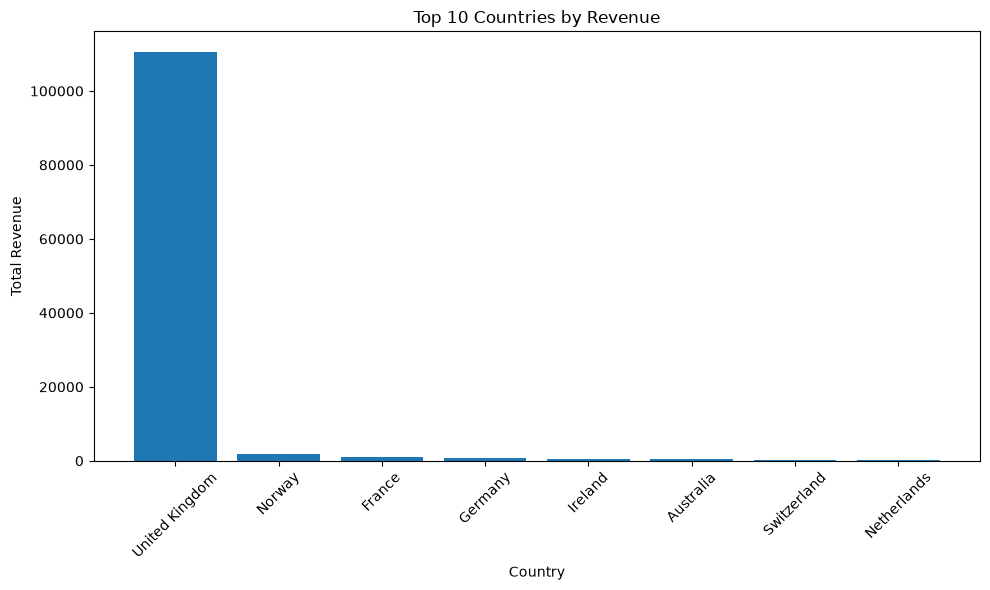

In [243]:
plt.figure(figsize=(10, 6))

plt.bar(
    country_highest_revenue.index,
    country_highest_revenue.values
)

plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

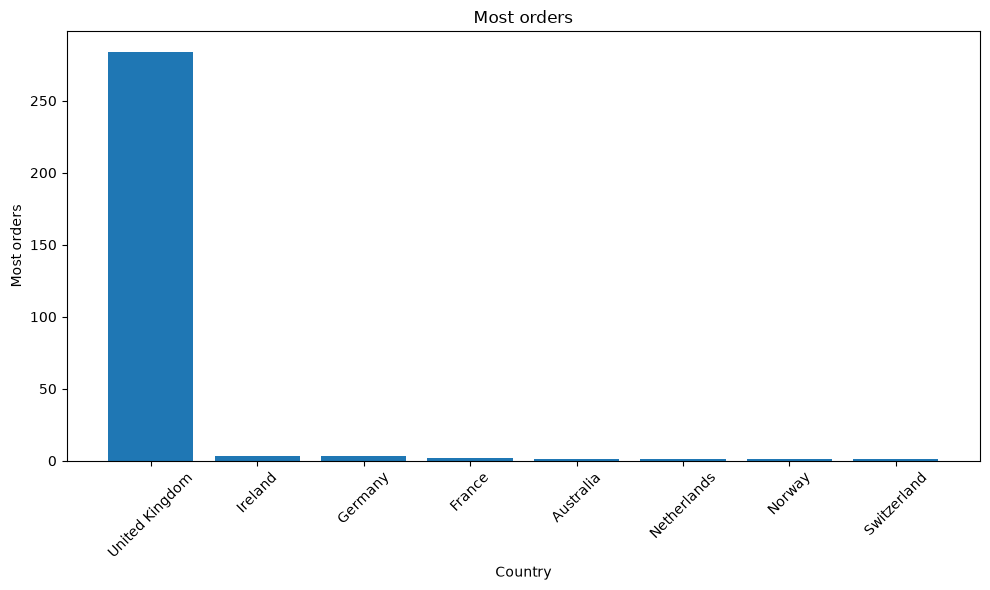

In [244]:
plt.figure(figsize=(10, 6))

plt.bar(
    most_orders.index,
    most_orders.values
)

plt.xlabel("Country")
plt.ylabel("Most orders")
plt.title("Most orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [246]:
monthly_revenue = (
    sales_df.groupby(["Year", "Month"])["Revenue"]
    .sum()
)

print(monthly_revenue)

Year  Month
2010  12       115615.8
Name: Revenue, dtype: float64


In [250]:
df["Month"].unique()


array([12], dtype=int32)